# Monte Carlo Methods

Monte Carlo methods are any process that consumes random numbers. These are part of computational algorithms which are based on random sampling to obtain numerical results. Monte Carlo methods are proved to be a very valuable and flexible computational tool in finance and is one of the most widely used methods for optimization and numerical integration problems.

These methods are widely used in high dimensional problems; pricing exotics and complex derivatives where closed form solutions are not directly available. Monte Carlo methods are not just adapted in pricing complex derivatives, It is also extensively used in estimating the portfolio risk such as Value-at-Risk and Expected Shortfall and used in the calculation of worst-case scenarios in stress testing. The downside to that is, it is very computational intensive and demanding.

**Monte Carlo Simulation**

A method of estimating the value of an unknown quantity using the principles of inferential statistics.

We take the population and then we sample it by drawing a proper subset. And then we make an inference about the population based upon some set of statistics we do on the sample.

And, the key fact that makes them work, that if we choose the sample at random, the sample will tend to exhibit the same properties as the population from which it is drawn.

**Option Pricing Techniques**

As with other option pricing techniques Monte Carlo methods are used to price options using what is essentially a three step process.

**Step 1:** Simulate potential price paths of the underlying asset.<br>
**Step 2:** Calculate the option payoff for each of these price paths.<br>
**Step 3:** Average the payoff and discount back to today to determine the option price.

## Section 1: Simulating Asset Prices

Next, we will simulate the asset price at maturity $S_{T}$. Following Black-Scholes-Merton where the underlying follows under risk neutrality, a geometric Brownian motion with a stochastic differential equation (SDE) is given as


\begin{equation*}
   dS_{t} = rS_{t}dt + σS_{t}dW_{t}
\end{equation*}

where $S_{t}$ is the price of the underlying at time $t$, σ is constant volatility, $r$ is the constant risk-free interest rate and $W$ is the brownian motion.<br>

Applying Euler discretization of SDE, we get

\begin{equation*}
   S_{t+{\delta}t} = S_t * (1 + {r {\delta}t + {\sigma} {\sqrt{\delta}t} w_{t})}
\end{equation*}

It is often more convenient to express in time stepping form

\begin{equation*}
   S_{t+{\delta}t} = S_t exp^{((r-\frac{1}2{\sigma}^2){\delta}t + {\sigma} {\sqrt{\delta}t} w_{t})}
\end{equation*}


The variable w is a standard normally distributed random variable, 0 < ${\delta}t$ < T, time interval. It also holds 0 < t ≤ T with T the final time horizon.

**Install Packages**

In [1]:
pip install opstrat

Note: you may need to restart the kernel to use updated packages.


**Import Libraries**

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Simulation Function for GBM paths
def simulate_gbm_paths(S0, r, sigma, T, n_paths, n_steps):

    dt = T / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = S0

    for t in range(1, n_steps + 1):
        z = np.random.standard_normal(n_paths)

        # Applying Euler discretization of SDE
        paths[:, t] = paths[:, t-1] * (1+ r*dt + sigma*np.sqrt(dt)*z)

        # Time stepping form
        # paths[:, t] = paths[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

    return paths

In [4]:
# Subsume into dataframe
paths = pd.DataFrame(simulate_gbm_paths(S0=100, r=0.05, sigma=0.2, T=1, n_paths=100000, n_steps=252))
paths

,0,1,2,3,4,5,6,7,8,9,...,243,244,245,246,247,248,249,250,251,252
0,100.0,100.029086,100.000958,99.423017,98.230248,98.390016,98.503985,98.265725,99.848910,101.450806,...,103.684712,103.347986,101.946008,102.362911,102.644851,103.424180,105.154423,104.670659,104.349764,103.623879
1,100.0,100.218632,100.055497,98.494502,98.297450,99.455202,99.873969,99.534231,101.177367,99.852268,...,111.237527,109.389025,109.235120,110.983760,110.778409,112.294385,113.112372,111.186483,112.989022,111.831331
2,100.0,97.632808,94.913970,94.375979,94.560135,95.388030,95.779689,95.360229,95.630526,93.780030,...,101.128157,101.934049,100.972557,99.263134,98.965240,100.590600,100.344731,98.449813,97.368675,95.732815
3,100.0,100.310277,102.015958,102.343065,101.178402,102.609287,103.365600,103.811027,103.644613,102.170316,...,111.269679,111.174260,110.206927,110.556787,110.687142,110.787420,111.495194,112.168056,110.737480,108.213739
4,100.0,99.604417,98.329946,95.936006,96.563898,95.489848,97.875190,100.412771,99.610816,101.255791,...,93.538038,92.897463,92.331188,92.056585,93.173531,93.696351,93.272090,93.996228,93.904046,94.033345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,100.0,98.492820,98.702595,96.349955,98.335770,98.467764,97.552089,97.163765,96.456859,96.995672,...,97.565339,97.966646,98.749452,99.107885,98.352068,97.671888,97.712995,97.013943,97.608511,95.347602
99996,100.0,99.717555,100.961745,104.125734,106.360603,105.855836,103.181555,102.973579,103.957304,104.524586,...,116.640302,116.141100,113.945037,114.483702,113.325193,110.142859,110.720400,109.826855,110.147362,109.254921
99997,100.0,98.560399,100.027565,102.702788,104.207165,101.953032,103.189923,106.680941,107.941560,108.597096,...,118.987249,117.896925,118.761531,121.322856,119.388765,118.451504,120.043087,120.150759,122.962336,122.389828
99998,100.0,98.880428,99.225424,99.692944,99.219693,97.974809,99.372692,99.656876,99.852777,99.006028,...,106.971396,107.083369,107.123836,106.495484,107.114729,106.222298,107.356920,107.966259,108.231380,107.849406


**Visualisation of Simulated Paths**

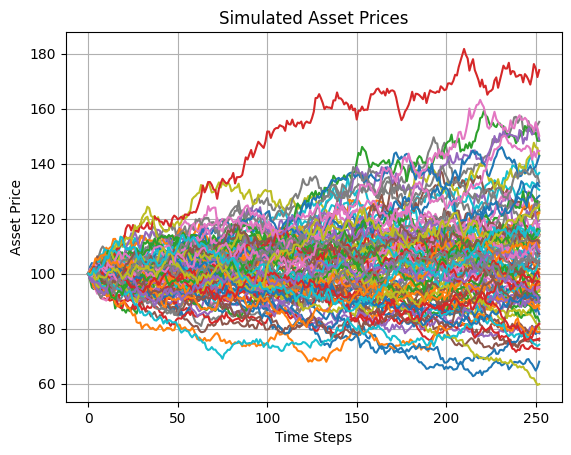

In [5]:
# paths = simulate_gbm_paths(S0=100, r=0.05, sigma=0.2, T=1, n_paths=10, n_steps=252)
plt.plot(paths[:100].T)
plt.title("Simulated Asset Prices")
plt.xlabel("Time Steps")
plt.ylabel("Asset Price")
plt.grid(True)
plt.show()


## Section 2: European Option

**Risk-Neutral Valuation**

A call option gives the holder of the option the right to buy the asset at a pre-defined price. A call buyer makes money if the price of the asset at maturity, denoted by $S_{T}$, is above the strike price $K$, otherwise it's worth nothing.

\begin{equation*}
   C_{T} = max (0, S_{T} - K)
\end{equation*}

The price of an option using a Monte Carlo simulation is the expected value of its future payoff. So at any date before maturity, denoted by $t$, the option's value is the present value of the expectation of its payoff at maturity, $T$.

\begin{equation*}
   C = PV(E[max (0,S_{T}-K)])
\end{equation*}

Under the risk-neutral framework, we assume the asset is going to earn, on average, the risk-free interest rate. Hence, the option value at time $t$ would simply be the discounted value of the expected payoff.

\begin{equation*}
   C = e^{−r(T−t)}(E[max (0,S_{T}-K)])
\end{equation*}

In [6]:
# European Option Price
def european_option_price(S0, K, r, sigma, T, n_paths, option_type='call'):

    # step 1
    paths = simulate_gbm_paths(S0, r, sigma, T, n_paths, n_steps=252)

    # step 2
    payoff = np.maximum(paths[:, -1] - K, 0) if option_type == 'call' else np.maximum(K - paths[:, -1], 0)

    # step 3
    price = np.exp(-r * T) * np.mean(payoff)

    return price

call_price = european_option_price(100, 100, 0.05, 0.2, 1, 50000, 'call')
put_price = european_option_price(100, 100, 0.05, 0.2, 1, 50000, 'put')

print("European Call Option Price:", round(call_price, 3))
print("European Put Option Price:", round(put_price, 3))

European Call Option Price: 10.454
European Put Option Price: 5.52


## Section 3: Asian Option

An Asian option is an option where the payoff depends on the average price of the underlying asset over a certain period of time. Averaging can be either be Arithmetic or Geometric. There are two types of Asian options: **fixed strike**, where averaging price is used in place of underlying price; and **fixed price**, where averaging price is used in place of strike.

We'll now price a fixed strike arthmetic average option using Monte Carlo simulation.

**The payoff of the options is given by**

\begin{equation*}
   C_{T} = max (0, \frac{1}T {\sum}^T_{i=1}S_{i} - K)
\end{equation*}

\begin{equation*}
   C_{T} = max (0, S_{Avg} - K)
\end{equation*}

where $S_{Avg}$ is the average price of the underlying asset over the life of the option.  To price an option using a Monte Carlo simulation we use a risk-neutral valuation, where the fair value for a derivative is the expected value of its future payoff. So at any date before maturity, denoted by $t$ , the option's value is the present value of the expectation of its payoff at maturity, $T$.

\begin{equation*}
   C = PV(E[max (0,S_{Avg}-K)])
\end{equation*}

Under the risk-neutral framework, we assume the asset is going to earn, on average, the risk-free interest rate. Hence, the option value at time $t$ would simply be the discounted value of the expected payoff.

\begin{equation*}
   C= e^{−r(T−t)}(E[max (0,S_{Avg}-K)])
\end{equation*}

In [7]:
def asian_option_price(S0, K, r, sigma, T, n_paths, n_steps, option_type='call'):

    # step 1
    paths = simulate_gbm_paths(S0, r, sigma, T, n_paths, n_steps)
    average_price = paths[:, 1:].mean(axis=1)

    # step 2
    payoff = np.maximum(average_price - K, 0) if option_type == 'call' else np.maximum(K - average_price, 0)

    # step 3
    return np.exp(-r * T) * np.mean(payoff)

asian_call_price = asian_option_price(100, 100, 0.05, 0.2, 1, 50000, 252, 'call')
asian_put_price = asian_option_price(100, 100, 0.05, 0.2, 1, 50000, 252, 'put')

print("Asian Call Option Price (Arithmetic Avg):", round(asian_call_price, 3))
print("Asian Put Option Price (Arithmetic Avg):", round(asian_put_price, 3))

Asian Call Option Price (Arithmetic Avg): 5.814
Asian Put Option Price (Arithmetic Avg): 3.397


## Section 4: Barrier Option

Barrier Options are path dependent exotic options whose payoff depends on whether the price of the underlying asset crosses a pre specified level (called the `barrier`) before the expiration. The four main types of barrier options are:

* Up-and-out
* Down-and-out
* Up-and-in
* Down-and-in

Refer Paul Wilmott on Quantitative Finance Chapter 23 — Barrier Options and Chapter 77 — Finite Difference Methods for One-factor Models for further details on barriers.

Next, we will price a Up-Out-Call barrier with and without rebate using Monte Carlo simulation. Barrier options can be priced using analytical solutions if we assume continuous monitoring of the barrier. However, in reality many barrier contracts specify discrete monitoring.

In a paper titled *A Continuity Correction for Discrete Barrier Option*, Mark Broadie, Paul Glasserman and Steven Kou have shown us that the discrete barrier options can be priced using continuous barrier formulas by applying a simple continuity correction to the barrier. The correction shifts the barrier away from the underlying by a factor of $$exp^{(\beta \sigma \sqrt{\Delta t})}$$

where $\beta \approx 0.5826$ and $\sigma$ is the underlying volatility, and $\Delta t$ is the time between monitoring instants. We will apply this continuity correction in our pricing method as well.

In [8]:
# Barrier Option Pricing
def barrier_option_price(S0, K, r, sigma, T, n_paths, n_steps, barrier=150, rebate=10):

    # Barrier shift - continuity correction for discrete monitoring
    dt = T / n_steps
    barrier_shift = barrier*np.exp(0.5826*sigma*np.sqrt(dt))

    paths = simulate_gbm_paths(S0, r, sigma, T, n_paths, n_steps)
    breached = np.any(paths >= barrier_shift, axis=1)
    final = paths[:, -1]

    payoff = np.where(~breached, np.maximum(final - K, 0), rebate)
    return np.exp(-r * T) * np.mean(payoff)

up_and_out_barrier_call = barrier_option_price(100, 100, 0.05, 0.2, 1, 50000, 252)
print("Up-and-Out Call Option Price:", round(up_and_out_barrier_call, 3))

Up-and-Out Call Option Price: 8.415


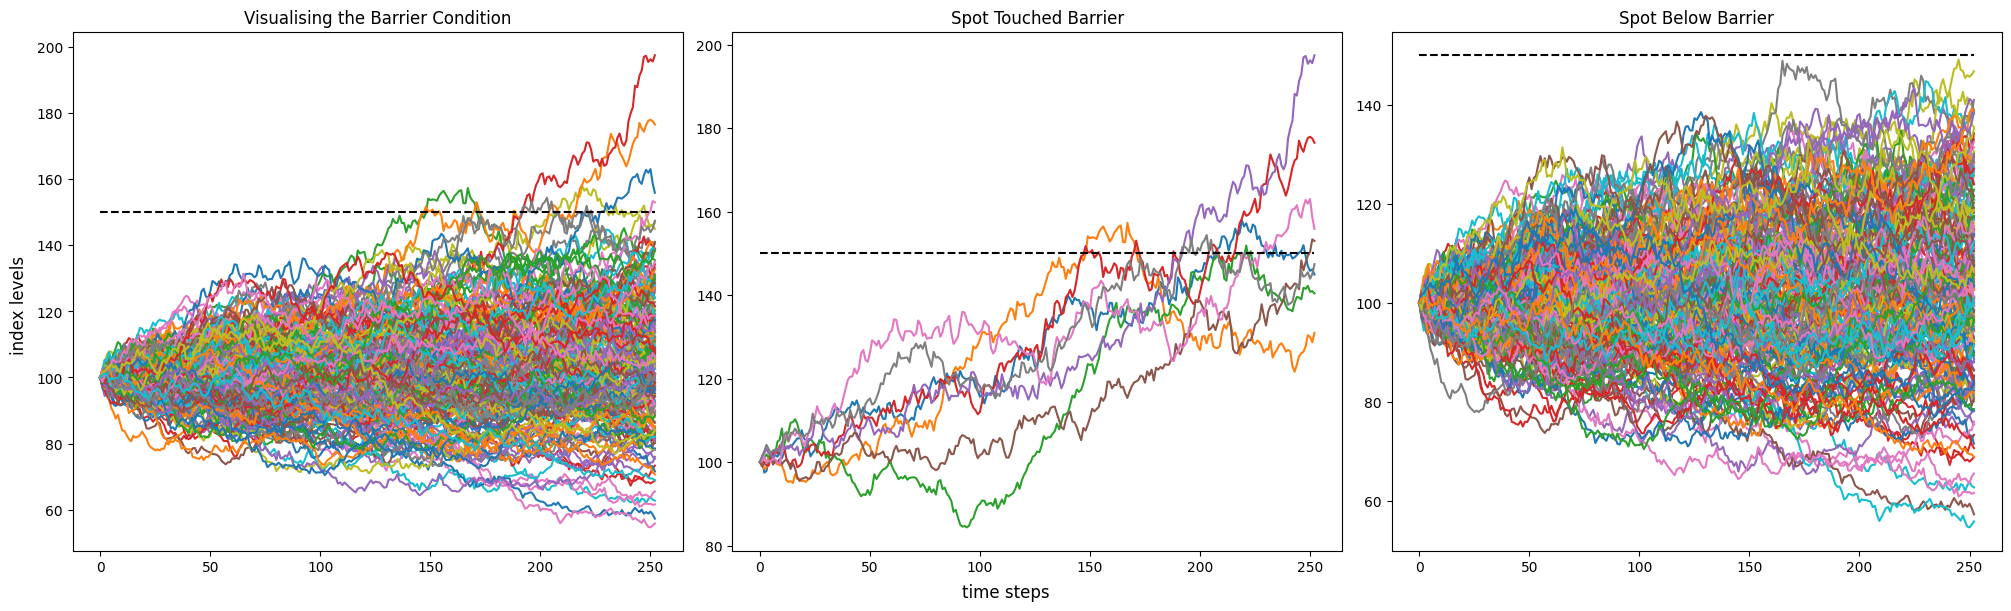

In [9]:
paths = simulate_gbm_paths(100, 0.05, 0.2, 1, 50000, 252)
barrier_shift = 150

figure, axes = plt.subplots(1,3, figsize=(20,6), constrained_layout=True)
title = ['Visualising the Barrier Condition', 'Spot Touched Barrier', 'Spot Below Barrier']

axes[0].plot(paths[:200, :].T)

for i in range(200):
    axes[1].plot(paths[i,:]) if paths[i,:].max() > barrier_shift else axes[2].plot(paths[i,:])

for i in range(3):
    axes[i].set_title(title[i])
    axes[i].hlines(barrier_shift, 0, 252, colors='k', linestyles='dashed')

figure.supxlabel('time steps')
figure.supylabel('index levels')

plt.show()

## Section 5: Variance Reduction Techniques

Monte Carlo simulations can suffer from high variance. Two common techniques to improve convergence are:

- **Antithetic Variates**: Uses negatively correlated paths to reduce variance.
- **Moment Matching**: Adjusts generated random numbers to match the theoretical mean and variance.


In [10]:
# Antithetic Variates
def european_option_price_antithetic(S0, K, r, sigma, T, n_paths, option_type='call'):
    dt = T
    z = np.random.randn(n_paths)
    z_antithetic = -z

    ST_1 = S0 * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
    ST_2 = S0 * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z_antithetic)

    if option_type == 'call':
        payoff = 0.5 * (np.maximum(ST_1 - K, 0) + np.maximum(ST_2 - K, 0))
    else:
        payoff = 0.5 * (np.maximum(K - ST_1, 0) + np.maximum(K - ST_2, 0))

    return np.exp(-r * T) * np.mean(payoff)

antithetic_call_price = european_option_price_antithetic(100, 100, 0.05, 0.2, 1, 100000, 'call')
print("European Call Price with Antithetic Variates:", round(antithetic_call_price, 4))

European Call Price with Antithetic Variates: 10.4325


In [11]:
# Moment Matching
def european_option_price_moment_matched(S0, K, r, sigma, T, n_paths, option_type='call'):
    z = np.random.standard_normal(n_paths)
    z = (z - np.mean(z)) / np.std(z)  # moment matching to mean=0, std=1

    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    if option_type == 'call':
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)

    return np.exp(-r * T) * np.mean(payoff)

moment_matched_call_price = european_option_price_moment_matched(100, 100, 0.05, 0.2, 1, 100000, 'call')
print("European Call Price with Moment Matching:", round(moment_matched_call_price, 4))


European Call Price with Moment Matching: 10.4532


**Quasi-Monte Carlo (QMC)** is another popular variance reduction technique. The core idea is to replace pseudo-random numbers with low-discrepancy deterministic sequences (like Sobol or Halton) to achieve faster convergence. These sequences fill the sampling space more uniformly than random draws.

In [12]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [13]:
# Import from scipy
from scipy.stats import qmc, norm

# Sobol QMC pricing function
def european_option_price_sobol(S0, K, r, sigma, T, n_paths, option_type='call'):

    # Generate Sobol samples in [0,1], then map to standard normal
    sobol = qmc.Sobol(d=1, scramble=True)
    u = sobol.random(n_paths)
    z = norm.ppf(u.ravel())  # Inverse transform to standard normal

    ST = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * z)

    if option_type == 'call':
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)

    return np.exp(-r * T) * np.mean(payoff)

# The balance properties of Sobol' points require n to be a power of 2.
sobol_price = european_option_price_sobol(100, 100, 0.05, 0.2, 1, 2**16, 'call')
print("European Call Option Price (Sobol QMC):", round(sobol_price, 4))

European Call Option Price (Sobol QMC): 10.4507


**Compare Variance Reductions Methods**

In [14]:
S0 = 100; K =100; r=0.05; sigma=0.2; T=1; n_paths=2**16; option_type='call'

# Comparison
results = {
    'Naive': european_option_price(S0, K, r, sigma, T, n_paths, option_type),
    'Antithetic': european_option_price_antithetic(S0, K, r, sigma, T, n_paths, option_type),
    'Moment Matched': european_option_price_moment_matched(S0, K, r, sigma, T, n_paths, option_type),
    'Sobol QMC': european_option_price_sobol(S0, K, r, sigma, T, n_paths, option_type)
}

# Display results
for method, price in results.items():
    print(f"{method:20s}: {price:.4f}")

Naive               : 10.4906
Antithetic          : 10.4447
Moment Matched      : 10.4469
Sobol QMC           : 10.4505


## Section 6: Also Read

📌 [How to price barrier option using quantlib-python](https://kannansi.medium.com/how-to-price-barrier-option-using-quantlib-python-ee4b1fff2448)

---
[Kannan Singaravelu](https://www.linkedin.com/in/kannansi)